In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv(r"C:\Users\DHARSHINI M\Desktop\AIML\spam-data.csv")

print(df.head())

   EmailLength  NumLinks  ContainsOffer  Spam
0           61         3              1     1
1          103         2              1     1
2           88         2              1     1
3           94         2              1     1
4           24         2              1     1


In [4]:
print("Shape of dataset:", df.shape)
print()

print("Column names:")
print(df.columns)
print()

print("Dataset information:")
print(df.info())
print()

print("Statistical summary:")
print(df.describe())
print()

print("Missing values:")
print(df.isnull().sum())

Shape of dataset: (80, 4)

Column names:
Index(['EmailLength', 'NumLinks', 'ContainsOffer', 'Spam'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   EmailLength    80 non-null     int64
 1   NumLinks       80 non-null     int64
 2   ContainsOffer  80 non-null     int64
 3   Spam           80 non-null     int64
dtypes: int64(4)
memory usage: 2.6 KB
None

Statistical summary:
       EmailLength   NumLinks  ContainsOffer       Spam
count    80.000000  80.000000      80.000000  80.000000
mean    140.487500   2.800000       0.500000   0.500000
std      85.537466   2.522807       0.503155   0.503155
min      24.000000   0.000000       0.000000   0.000000
25%      82.750000   1.000000       0.000000   0.000000
50%     108.000000   2.000000       0.500000   0.500000
75%     200.750000   5.000000       1.000000   1.0

In [8]:
x = df[["EmailLength", "NumLinks", "ContainsOffer"]]

y = df[["Spam"]]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42
)

In [10]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [11]:
model = LogisticRegression()

model.fit(x_train, y_train)

C:\Users\DHARSHINI M\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(x_test)

In [14]:
print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy Score
1.0

Confusion Matrix
[[ 9  0]
 [ 0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



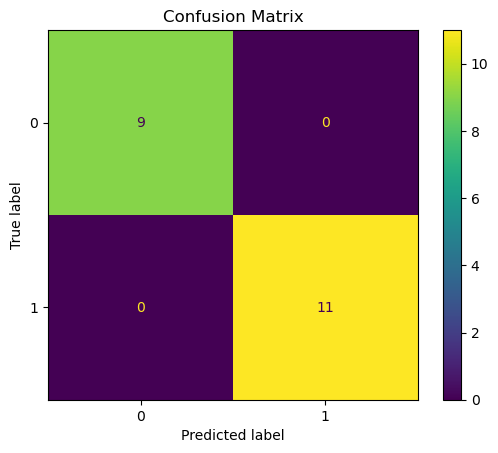

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()